## Classification: Airplane, Automobile, Bird, Cat, Dog

### Installs for fastai

In [1]:
#NB: Kaggle requires phone verification to use the internet or a GPU. If you haven't done that yet, the cell below will fail
#    This code is only here to check that your internet is enabled. It doesn't do anything else.
#    Here's a help thread on getting your phone number verified: https://www.kaggle.com/product-feedback/135367

import socket,warnings
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_DGRAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")

# It's a good idea to ensure you're running the latest version of any libraries you need.
# `!pip install -Uqq <libraries>` upgrades to the latest version of <libraries>
# NB: You can safely ignore any warnings or errors pip spits out about running as root or incompatibilities
import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')

if iskaggle:
    !pip install -Uqq fastai

## Step 1: Download images of birds and non-birds

In [2]:
!pip install -Uqq duckduckgo_search
!pip install -Uqq scikit-learn

In [3]:
from duckduckgo_search import DDGS
from fastcore.all import *
from fastai.vision.all import *
from fastdownload import download_url
from time import sleep
import os
from glob import glob
import sklearn
from sklearn.manifold import TSNE 
ddgs = DDGS()
def search_images(term, max_images=600): return L(ddgs.images(term, max_results=max_images)).itemgot('image')

/home/vscode/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Grabbing 600 examples of each search type and saving each group of photos to a different folder:

In [ ]:
searches = 'airplane','automobile','bird','cat','dog'
path = Path('elec4630_classification')

# Download images
for o in searches:
    dest = (path/o)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} photo'))
    sleep(10)
    for file in glob(f"{dest}/*.fpx"): # remove fpx files which cause problems with resize_images
        os.unlink(file)
    resize_images(path/o, max_size=400, dest=path/o)

# Verify and clean images
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

### Building a data block with batch_size 64

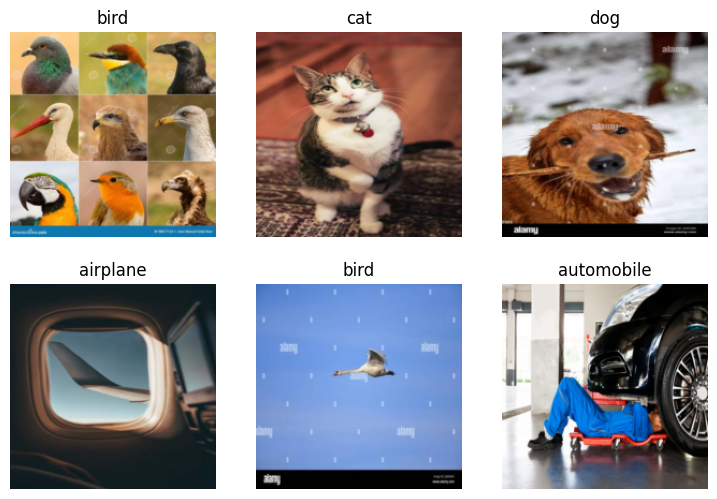

In [28]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, batch_size=64)
dls.show_batch(max_n=6)

### Training Resnet101 with fine tune, and finding the optimal training rate

In [23]:
learn = vision_learner(dls, resnet101, metrics=error_rate)
print(learn.loss_func)
learn.fine_tune(2, 3e-3)

FlattenedLoss of CrossEntropyLoss()


epoch,train_loss,valid_loss,error_rate,time
0,0.635771,0.297281,0.069018,00:18


epoch,train_loss,valid_loss,error_rate,time
0,0.186262,0.418329,0.076687,00:21
1,0.118017,0.306271,0.058282,00:20


## Analysing all input images with the network, and applying TSNE

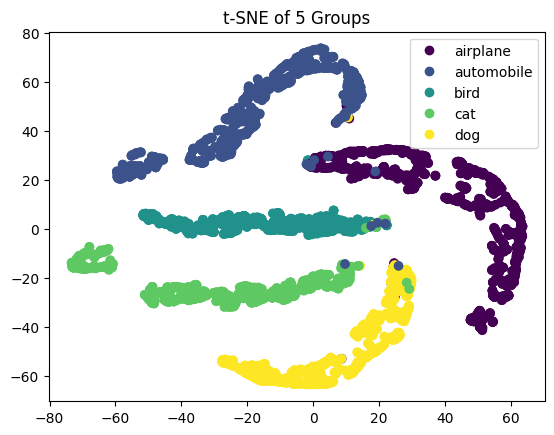

In [24]:
img_files = get_image_files(path)
features = []
colorMap = []
for img_path in img_files:
    _, _, feature_likeness = learn.predict(PILImage.create(img_path))
    features.append(feature_likeness)
    for (i, match) in enumerate(["airplane", "automobile", "bird", "cat", "dog"]):
        subGroup = str(img_path).split('/')[1]
        if subGroup == match:
            colorMap.append(i)

features = np.array(features)
tsne = TSNE(n_components=2, random_state=42)
res = tsne.fit_transform(features)
scat = plt.scatter(res[:, 0], res[:, 1], c=colorMap, cmap='viridis', label=["airplane", "automobile", "bird", "cat", "dog"])
plt.legend(handles=scat.legend_elements()[0], labels=["airplane", "automobile", "bird", "cat", "dog"])
plt.title("t-SNE of 5 Groups")
plt.savefig("./tsne.pdf")

# Example output of testing the predictions of the Model

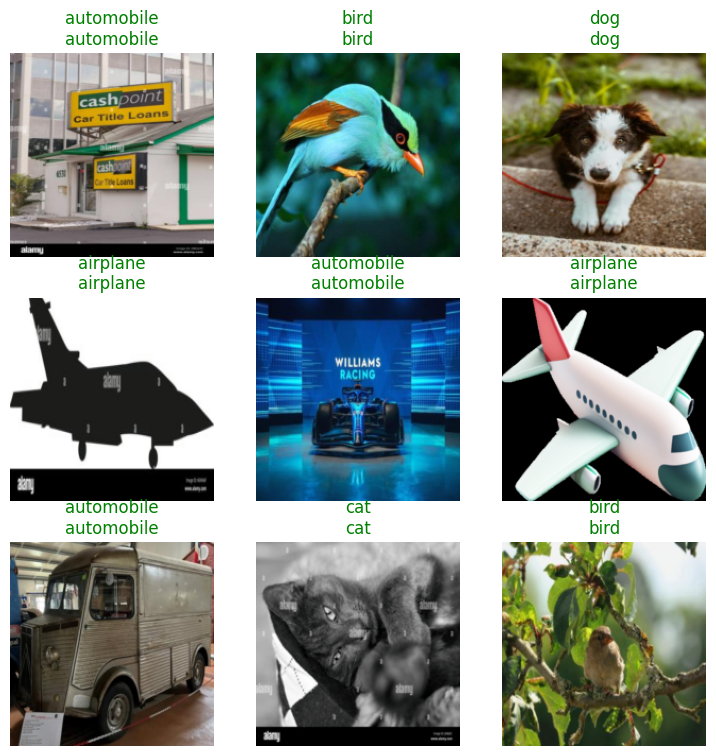

In [25]:
learn.show_results()

## Some of the more conflicted outputs which the model had trouble allocating

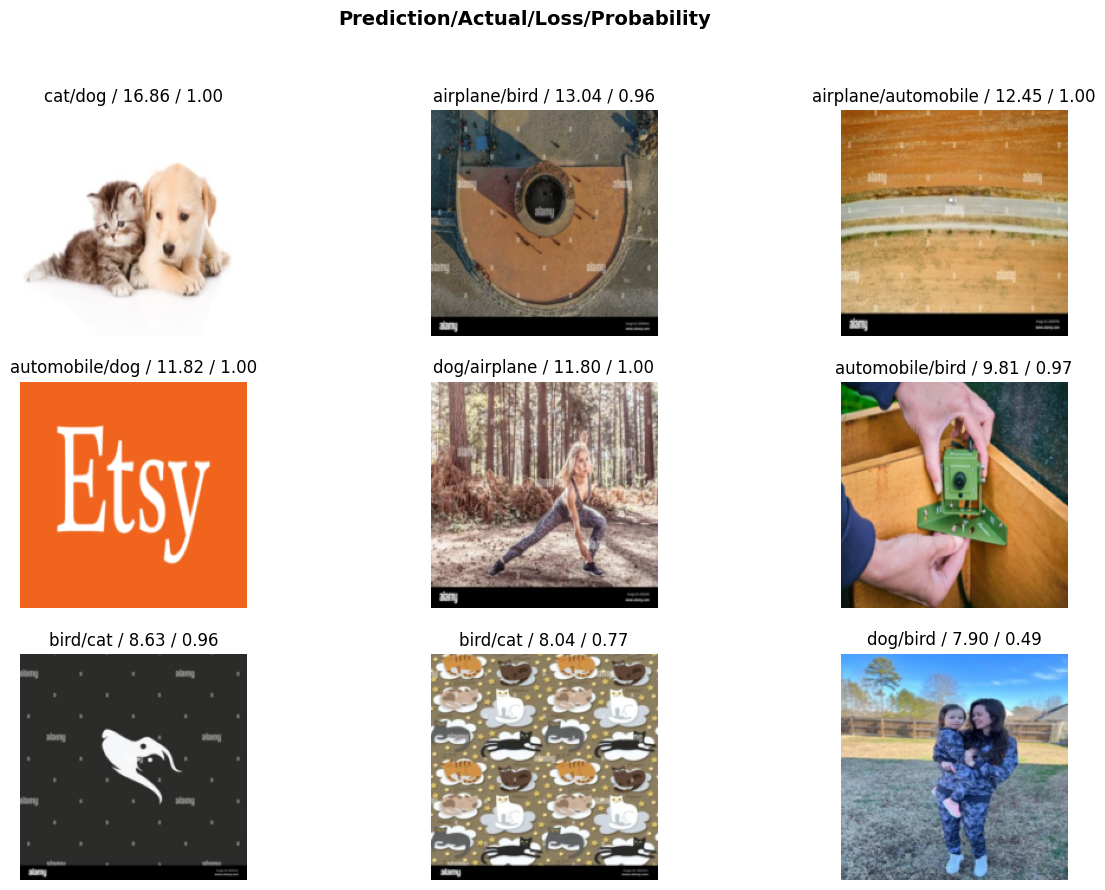

In [26]:
interp = Interpretation.from_learner(learn)
interp.plot_top_losses(9, figsize=(15,10))

## The Confusion matrix for which images where misallocated in their predictions

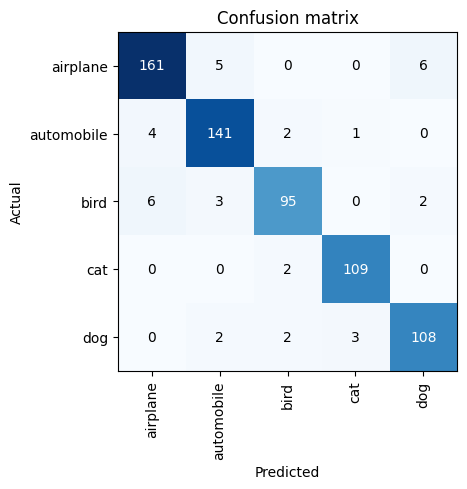

In [27]:
classif = ClassificationInterpretation.from_learner(learn)
classif.plot_confusion_matrix()